# BIOSNAP Model Comparison (50 Epochs)

This notebook compares the performance of the **Baseline** model and the **Improved Residual** model on the BIOSNAP dataset. Both models were configured to train for 50 epochs.

In [1]:
import os
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

In [2]:
def load_history(file_path):
    if not os.path.exists(file_path):
        print(f"Warning: File not found: {file_path}")
        return None
    with open(file_path, 'r') as f:
        return json.load(f)

# Define paths to the history files
base_path = "best_models"
model_paths = {
    "Baseline": os.path.join(base_path, "biosnap_baseline_no_contrast", "history.json"),
    "Residual (Improved)": os.path.join(base_path, "biosnap_residual_improved", "history.json")
}

# Load data
histories = {}
for name, path in model_paths.items():
    hist = load_history(path)
    if hist:
        histories[name] = hist

In [3]:
# Extract metrics
data = []
for name, hist in histories.items():
    epochs = range(1, len(hist['val_aupr']) + 1)
    for i, epoch in enumerate(epochs):
        data.append({
            'Model': name,
            'Epoch': epoch,
            'Validation AUPR': hist['val_aupr'][i],
            'Validation AUROC': hist['val_auroc'][i]
        })

df = pd.DataFrame(data)
df.head()

,Model,Epoch,Validation AUPR,Validation AUROC
0,Baseline,1,0.855058,0.828493
1,Baseline,2,0.886888,0.864281
2,Baseline,3,0.906455,0.886715
3,Baseline,4,0.914510,0.897060
4,Baseline,5,0.921631,0.905325


## Validation AUPR Comparison

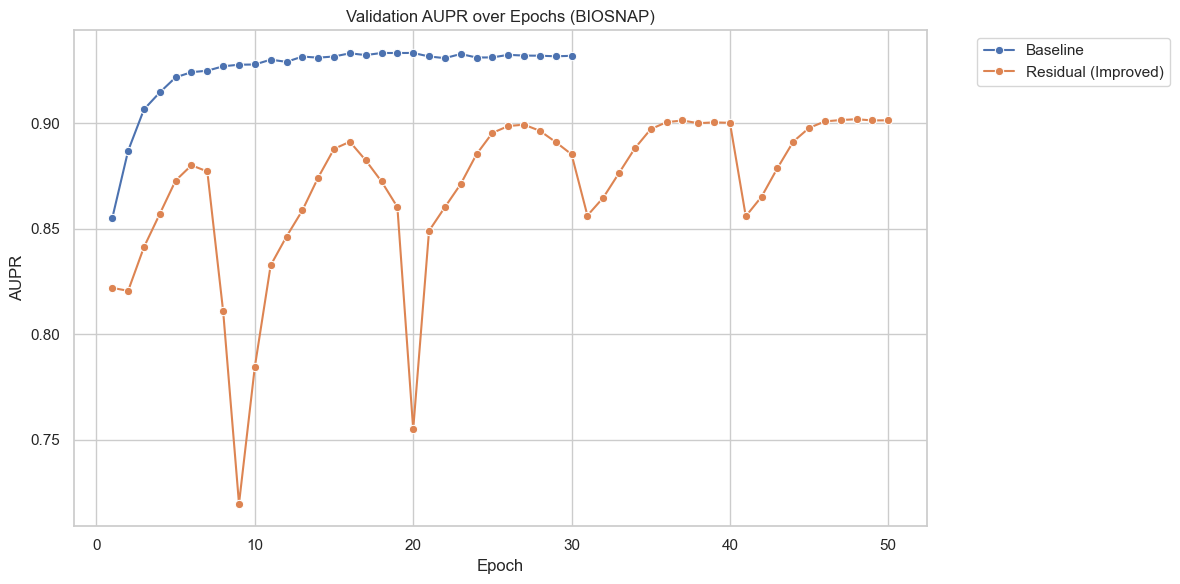

In [4]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Epoch', y='Validation AUPR', hue='Model', marker='o')
plt.title('Validation AUPR over Epochs (BIOSNAP)')
plt.xlabel('Epoch')
plt.ylabel('AUPR')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Validation AUROC Comparison

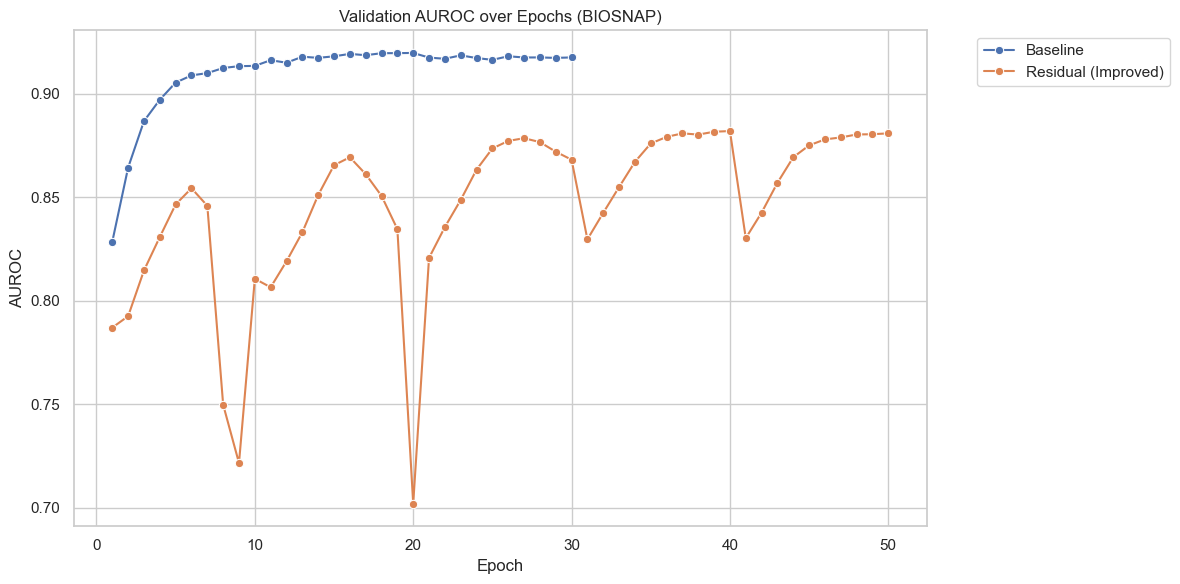

In [5]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Epoch', y='Validation AUROC', hue='Model', marker='o')
plt.title('Validation AUROC over Epochs (BIOSNAP)')
plt.xlabel('Epoch')
plt.ylabel('AUROC')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Max Performance Summary

In [6]:
summary = df.groupby('Model')[['Validation AUPR', 'Validation AUROC']].max().sort_values('Validation AUPR', ascending=False)
summary

,Validation AUPR,Validation AUROC
Model,,
Baseline,0.933175,0.919642
Residual (Improved),0.901802,0.881911
